In [11]:
%pip install "numpy<2"

   ---------------------------------------- 0.0/15.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/15.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/15.5 MB ? eta -:--:--
    --------------------------------------- 0.3/15.5 MB ? eta -:--:--
    --------------------------------------- 0.3/15.5 MB ? eta -:--:--
   - -------------------------------------- 0.5/15.5 MB 598.5 kB/s eta 0:00:26
   - -------------------------------------- 0.5/15.5 MB 598.5 kB/s eta 0:00:26
   -- ------------------------------------- 0.8/15.5 MB 524.3 kB/s eta 0:00:29
   -- ------------------------------------- 0.8/15.5 MB 524.3 kB/s eta 0:00:29
   -- ------------------------------------- 0.8/15.5 MB 524.3 kB/s eta 0:00:29
   -- ------------------------------------- 1.0/15.5 MB 508.4 kB/s eta 0:00:29
   -- ------------------------------------- 1.0/15.5 MB 508.4 kB/s eta 0:00:29
   --- ------------------------------------ 1.3/15.5 MB 528.5 kB/s eta 0:00:27
   --- -----------

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gensim 4.3.3 requires scipy<1.14.0,>=1.7.0, but you have scipy 1.17.1 which is incompatible.
opencv-python-headless 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
streamlit 1.37.1 requires pandas<3,>=1.3.0, but you have pandas 3.0.1 which is incompatible.


In [1]:
import pandas as pd
import numpy as np

c:\Users\asus\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\asus\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


## Load Datasets

In [2]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
sample = pd.read_csv('sample_submission.csv')

train.head()
train.info()
train.describe()

<class 'pandas.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                630000 non-null  int64  
 1   age               630000 non-null  int64  
 2   gender            630000 non-null  str    
 3   course            630000 non-null  str    
 4   study_hours       630000 non-null  float64
 5   class_attendance  630000 non-null  float64
 6   internet_access   630000 non-null  str    
 7   sleep_hours       630000 non-null  float64
 8   sleep_quality     630000 non-null  str    
 9   study_method      630000 non-null  str    
 10  facility_rating   630000 non-null  str    
 11  exam_difficulty   630000 non-null  str    
 12  exam_score        630000 non-null  float64
dtypes: float64(4), int64(2), str(7)
memory usage: 84.8 MB


,id,age,study_hours,class_attendance,sleep_hours,exam_score
count,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000
mean,314999.500000,20.545821,4.002337,71.987261,7.072758,62.506672
std,181865.479132,2.260238,2.359880,17.430098,1.744811,18.916884
min,0.000000,17.000000,0.080000,40.600000,4.100000,19.599000
25%,157499.750000,19.000000,1.970000,57.000000,5.600000,48.800000
50%,314999.500000,21.000000,4.000000,72.600000,7.100000,62.600000
75%,472499.250000,23.000000,6.050000,87.200000,8.600000,76.300000
max,629999.000000,24.000000,7.910000,99.400000,9.900000,100.000000


## Process

In [3]:
# feature engineering

# pengaruh jam belajar dan jam tidur terhadap skor ujian
train['study_per_sleep'] = train['study_hours'] / (train['sleep_hours'] + 1)

# pengaruh jam belajar dan kehadiran terhadap skor ujian
train['study_per_attendance'] = train['study_hours'] * train['class_attendance']

test['study_per_sleep'] = test['study_hours'] / (test['sleep_hours'] + 1)
test['study_per_attendance'] = test['study_hours'] * test['class_attendance']

In [4]:
# pisahkan fitur dan target
X = train.drop(['exam_score', 'id'], axis=1)
y = train['exam_score']

# simpan id test
test_id = test['id']
test = test.drop('id', axis=1)

In [5]:
from sklearn.preprocessing import LabelEncoder
# encoding
# X = pd.get_dummies(X)
# test = pd.get_dummies(test)

# encoding untuk fitur kategorikal
le = LabelEncoder()

for col in X.select_dtypes(include='object').columns:
    X[col] = le.fit_transform(X[col])
    test[col] = le.transform(test[col])

# samakan kolom
X, test = X.align(test, join='left', axis=1, fill_value=0)

C:\Users\asus\AppData\Local\Temp\ipykernel_10936\1124320068.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in X.select_dtypes(include='object').columns:


In [6]:
X.head()

,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,study_per_sleep,study_per_attendance
0,21,0,1,7.91,98.8,0,4.9,0,3,1,0,1.340678,781.508
1,18,2,6,4.95,94.8,1,4.7,2,4,2,2,0.868421,469.260
2,20,0,1,4.68,92.6,1,5.8,2,0,0,2,0.688235,433.368
3,19,1,1,2.00,49.5,1,8.3,0,1,0,2,0.215054,99.000
4,23,1,5,7.65,86.9,1,9.6,1,4,0,0,0.721698,664.785


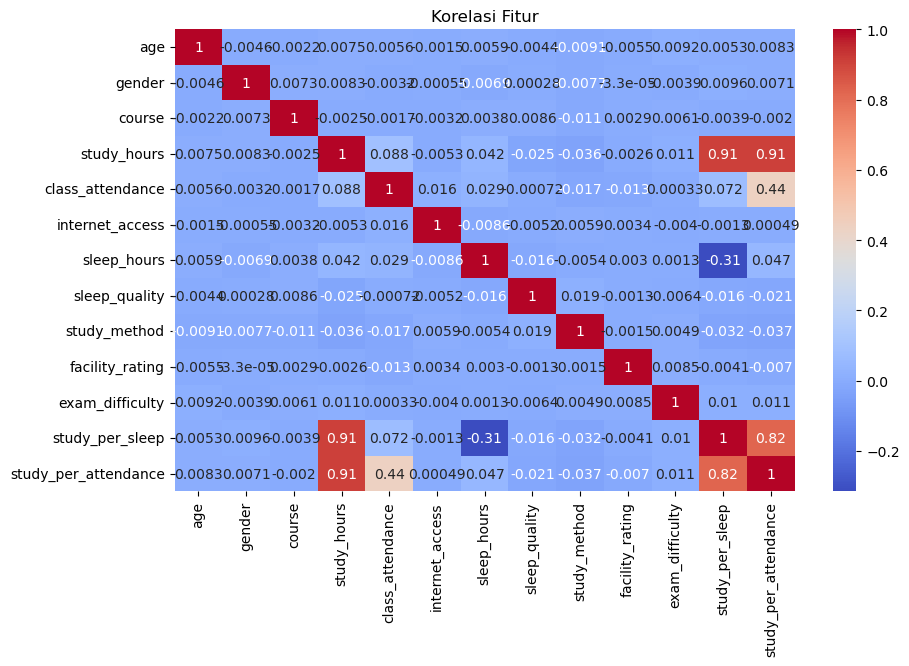

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(X.corr(), annot=True, cmap='coolwarm')
plt.title('Korelasi Fitur')
plt.show()

In [8]:
from sklearn.model_selection import train_test_split

# split validation
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
%pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.5/101.7 MB 645.7 kB/s eta 0:02:37
   ---------------------------------------- 0.5/101.7 MB 645.7 kB/s eta 0:02:37
   ---------------------------------------- 0.8/101.7 MB 657.8 kB/s eta 0:02:34
   ---------------------------------------- 0.8/101.7 MB 657.8 kB/s eta 0:02:34
   ---------------------------------------- 1.0/101.7 MB 662.0 kB/s eta 0:02:33
   ---------------------------------------- 1.0/101.7 MB 662.0 kB/s eta 0:02:33
    --------------------------------------- 1.3/101.7 MB 657.8 kB/s eta 0:02:33
    --------------------------------------- 1.3/101.7 MB 657.8 kB/s eta 0:02:33
    --------------------------------------- 1.6/101.7 MB 645.4 kB/s eta 0:02

In [ ]:
from sklearn.ensemble import RandomForestRegressor as rfr
from sklearn.linear_model import LinearRegression as lr
from xgboost import XGBRegressor as xgb

# model
models = { "Random Forest": rfr(n_estimators=200,max_depth=15, min_samples_split=5, random_state=42, n_jobs=-1),
              "Linear Regression": lr(),
              "XGBoost": xgb(n_estimators=300, learning_rate=0.05, max_depth=6, subsample=0.8, colsample_bytree=0.8, random_state=42) }

# model.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [80]:
from sklearn.metrics import mean_squared_error

# evaluasi
pred_val = model.predict(X_val)

rmse = np.sqrt(mean_squared_error(y_val, pred_val))
print(f'RMSE: {rmse}')

RMSE: 8.928256792436304


In [81]:
# train model dengan data penuh
model.fit(X,y)

# prediksi
pred = model.predict(test)

In [82]:
submission = sample.copy()
submission['exam_score'] = pred

submission.to_csv('submission.csv', index=False)

print("Submission file berhasil dibuat!")

Submission file berhasil dibuat!


In [83]:
submission.head()

,id,exam_score
0,630000,71.757317
1,630001,70.882383
2,630002,86.212119
3,630003,53.155854
4,630004,46.964881


In [84]:
sample.head()

,id,exam_score
0,630000,0
1,630001,0
2,630002,0
3,630003,0
4,630004,0


In [85]:
submission.info()
print("\n------------------------------------------\n")
sample.info()

<class 'pandas.DataFrame'>
RangeIndex: 270000 entries, 0 to 269999
Data columns (total 2 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   id          270000 non-null  int64  
 1   exam_score  270000 non-null  float64
dtypes: float64(1), int64(1)
memory usage: 4.1 MB

------------------------------------------

<class 'pandas.DataFrame'>
RangeIndex: 270000 entries, 0 to 269999
Data columns (total 2 columns):
 #   Column      Non-Null Count   Dtype
---  ------      --------------   -----
 0   id          270000 non-null  int64
 1   exam_score  270000 non-null  int64
dtypes: int64(2)
memory usage: 4.1 MB


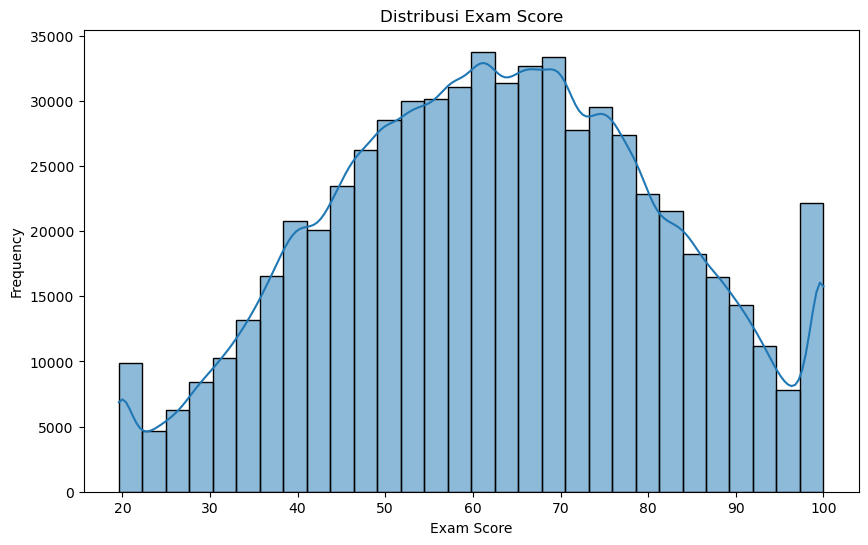

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.histplot(train['exam_score'], bins=30, kde=True)
plt.title('Distribusi Exam Score')
plt.xlabel('Exam Score')
plt.ylabel('Frequency')
plt.show()

In [86]:
pd.set_option('display.max_columns', None)
X.head()

,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,study_per_sleep,study_per_attendance
0,21,0,1,7.91,98.8,0,4.9,0,3,1,0,1.340678,781.508
1,18,2,6,4.95,94.8,1,4.7,2,4,2,2,0.868421,469.260
2,20,0,1,4.68,92.6,1,5.8,2,0,0,2,0.688235,433.368
3,19,1,1,2.00,49.5,1,8.3,0,1,0,2,0.215054,99.000
4,23,1,5,7.65,86.9,1,9.6,1,4,0,0,0.721698,664.785


In [87]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 13 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   age                   630000 non-null  int64  
 1   gender                630000 non-null  int32  
 2   course                630000 non-null  int32  
 3   study_hours           630000 non-null  float64
 4   class_attendance      630000 non-null  float64
 5   internet_access       630000 non-null  int32  
 6   sleep_hours           630000 non-null  float64
 7   sleep_quality         630000 non-null  int32  
 8   study_method          630000 non-null  int32  
 9   facility_rating       630000 non-null  int32  
 10  exam_difficulty       630000 non-null  int32  
 11  study_per_sleep       630000 non-null  float64
 12  study_per_attendance  630000 non-null  float64
dtypes: float64(5), int32(7), int64(1)
memory usage: 45.7 MB
